In [20]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [21]:
# Define State
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [22]:
def calculate_bmi(state: BMIState) -> BMIState:
    state['bmi'] = state['weight_kg'] / (state['height_m'] ** 2)
    return state

In [23]:
def calculate_category(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state

In [24]:
# Define Graph
graph = StateGraph(BMIState)

# define nodes
graph.add_node('calculate_bmi_node', calculate_bmi)
graph.add_node('calculate_category', calculate_category)

#define edges
graph.add_edge(START, 'calculate_bmi_node')
graph.add_edge('calculate_bmi_node', 'calculate_category')
graph.add_edge('calculate_category', END)

#complie graph
workflow = graph.compile()


In [27]:
#execute graph
initial_state = {'weight_kg': 81, 'height_m': 1.55, 'bmi': 0}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 81, 'height_m': 1.55, 'bmi': 33.71488033298647, 'category': 'Obesity'}


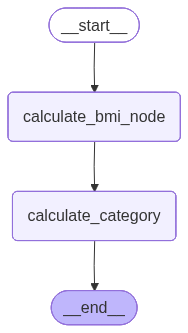

In [28]:
workflow